In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [33]:
df = pd.read_csv("data/HR.csv")
df.head()

,Patient_ID,Respiratory_Rate,Oxygen_Saturation,O2_Scale,Systolic_BP,Heart_Rate,Temperature,Consciousness,On_Oxygen,Risk_Level
0,P0522,25.0,96.0,1.0,97.0,107.0,37.5,A,0.0,Medium
1,P0738,28.0,92.0,2.0,116.0,151.0,NaN,P,1.0,High
2,P0741,29.0,91.0,1.0,79.0,135.0,38.4,A,0.0,High
3,P0661,24.0,96.0,NaN,95.0,92.0,37.3,A,0.0,Medium
4,P0412,20.0,96.0,1.0,97.0,97.0,NaN,A,NaN,Low


In [34]:
df.isnull().sum()

Patient_ID           100
Respiratory_Rate     100
Oxygen_Saturation    100
O2_Scale             100
Systolic_BP          100
Heart_Rate           100
Temperature          100
Consciousness        100
On_Oxygen            100
Risk_Level             0
dtype: int64

In [35]:
numerical_cols = df.select_dtypes(include=np.number).columns
categorical_cols = df.select_dtypes(exclude=np.number).columns

In [36]:
cat_imputer = SimpleImputer(strategy='most_frequent')
df[categorical_cols] = cat_imputer.fit_transform(df[categorical_cols])

In [37]:
df.describe()

,Respiratory_Rate,Oxygen_Saturation,O2_Scale,Systolic_BP,Heart_Rate,Temperature,On_Oxygen
count,900.000000,900.000000,900.000000,900.000000,900.000000,900.000000,900.000000
mean,21.635556,92.573333,1.118889,106.313333,98.525556,37.919667,0.277778
std,5.342180,4.527282,0.323838,17.939015,19.713984,1.117284,0.448152
min,12.000000,74.000000,1.000000,50.000000,60.000000,35.800000,0.000000
25%,17.000000,90.000000,1.000000,94.750000,85.000000,37.000000,0.000000
50%,20.000000,94.000000,1.000000,109.000000,95.500000,37.800000,0.000000
75%,25.000000,96.000000,1.000000,119.000000,109.000000,38.600000,1.000000
max,40.000000,100.000000,2.000000,146.000000,163.000000,41.800000,1.000000


In [38]:
df['Risk_Level'].value_counts()

Risk_Level
Medium    306
High      279
Low       255
Normal    160
Name: count, dtype: int64

In [39]:
df.drop(columns=['Patient_ID'], inplace=True)

In [40]:
from sklearn.preprocessing import LabelEncoder

# Consciousness
le_con = LabelEncoder()
df['Consciousness'] = le_con.fit_transform(df['Consciousness'])

# Target
le = LabelEncoder()
df['Risk_Level'] = le.fit_transform(df['Risk_Level'])

In [44]:
print(df.dtypes)

Respiratory_Rate     float64
Oxygen_Saturation    float64
O2_Scale             float64
Systolic_BP          float64
Heart_Rate           float64
Temperature          float64
Consciousness          int32
On_Oxygen            float64
Risk_Level             int32
dtype: object


In [45]:
# STEP 1: Create X and y again
X = df.drop('Risk_Level', axis=1)
y = df['Risk_Level']

# STEP 2: Split again
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [47]:
df.fillna(df.mean(numeric_only=True), inplace=True)

In [48]:
for col in df.select_dtypes(include='object').columns:
    df[col].fillna(df[col].mode()[0], inplace=True)

In [49]:
# Encode again
from sklearn.preprocessing import LabelEncoder

le_con = LabelEncoder()
df['Consciousness'] = le_con.fit_transform(df['Consciousness'])

le = LabelEncoder()
df['Risk_Level'] = le.fit_transform(df['Risk_Level'])

# Split again
X = df.drop('Risk_Level', axis=1)
y = df['Risk_Level']

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [53]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    min_samples_split=10,
    min_samples_leaf=4,
    class_weight='balanced',
    random_state=42
)

rf.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', max_depth=10,
                       min_samples_leaf=4, min_samples_split=10,
                       n_estimators=200, random_state=42)

In [54]:
y_pred = rf.predict(X_test)

In [55]:
from sklearn.metrics import accuracy_score

train_pred = rf.predict(X_train)

print("Training Accuracy:", accuracy_score(y_train, train_pred))
print("Testing Accuracy:", accuracy_score(y_test, y_pred))

Training Accuracy: 0.96625
Testing Accuracy: 0.94


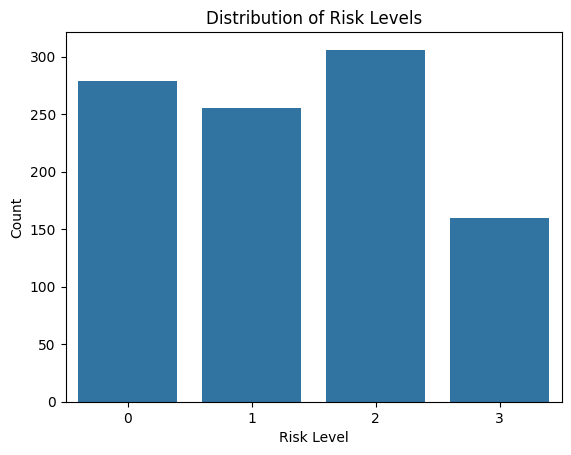

In [56]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='Risk_Level', data=df)
plt.title("Distribution of Risk Levels")
plt.xlabel("Risk Level")
plt.ylabel("Count")
plt.show()

"The count plot shows the distribution of different risk levels in the dataset. It helps identify class imbalance."

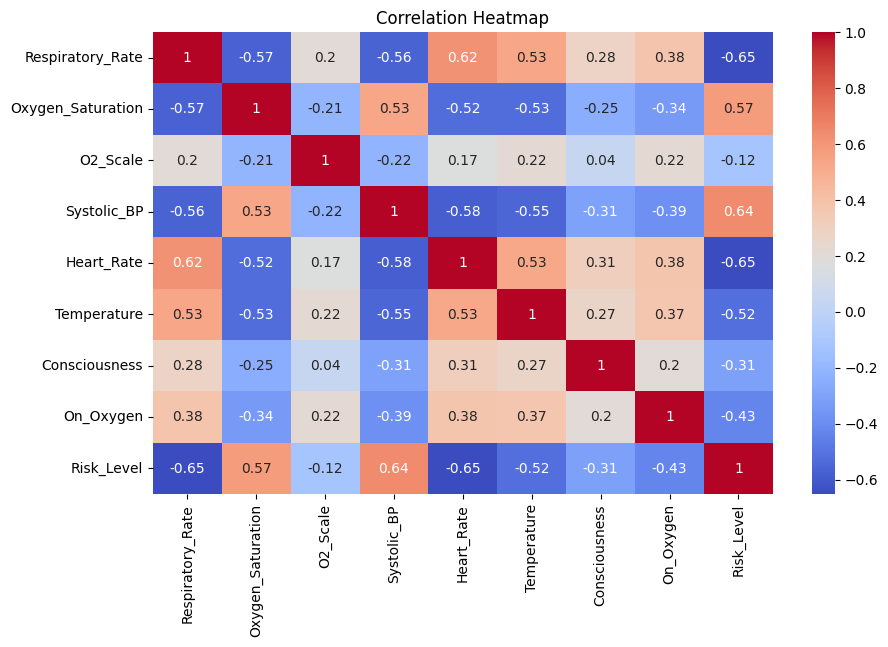

In [58]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

"The correlation heatmap shows relationships between features. It helps understand which variables influence the prediction."

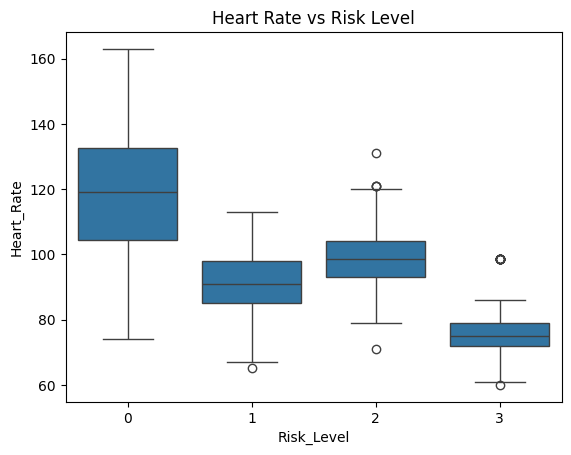

In [59]:
sns.boxplot(x='Risk_Level', y='Heart_Rate', data=df)
plt.title("Heart Rate vs Risk Level")
plt.show()

"The box plot shows the distribution of heart rate across different risk levels, highlighting variations, spread, and possible outliers in each category."

In [60]:
import pickle

pickle.dump(le_con, open("consciousness_encoder.pkl", "wb"))

A Random Forest model was built to predict health risk levels after preprocessing the dataset, handling missing values, and encoding categorical features. The model achieved high accuracy and was deployed using Flask for real-time predictions.